# Authorship Verification with **Unmasking** (Hands-on)

In this notebook, you build a simplified **unmasking** authorship detector ([Koppel & Schler (2004)](https://dl.acm.org/doi/pdf/10.1145/1015330.1015448]); later generalized by [Bevendorff et al. (2019)](https://aclanthology.org/N19-1068.pdf)).

**Core idea:**
For two texts $A$ and $B$.
1. Split each text into chunks ($\ge$ 500 worsd length).
2. Use the 250 words with highest average frequency in $A$ and $B$ as features.
3. Obtain 10-fold cross-validation accuracy between $A$ and $B$ with a linear SVM kernel.
4. Repeatedly remove the three most discriminative (positive and negative) features each fold.
5. If any features are left: Go to step 3.
6. Track how quickly classification accuracy drops.

A **fast drop** suggests that only a few superficial features distinguished the texts → *more consistent with the same author/style*.
A **slow drop** suggests many stable differences remain even after removing top features → *more consistent with different authors/styles*.

We use example texts from `nltk.book`.


## Learning goals

By the end, you can:
- implement the main steps of unmasking (chunking → feature matrix → iterative deconstruction)
- explain what an unmasking curve means and what it *doesn't* prove
- explore how design choices (chunk size, features, CV folds) affect results


## Setup

In [ ]:
import re
from collections import Counter
from dataclasses import dataclass
from typing import List, Sequence

import numpy as np
import matplotlib.pyplot as plt

import nltk
nltk.download("book", quiet=True)

from sklearn.model_selection import StratifiedKFold, cross_validate
from sklearn.svm import LinearSVC
from sklearn.utils import shuffle

RNG = np.random.default_rng(0)


## Load example texts (`nltk.book`)

`nltk.book` comes with a few classic corpora. We'll use them as convenient, reproducible examples.


In [2]:
from nltk.book import text1, text2, text3, text4, text6

print("text1:", text1.name)
print("text2:", text2.name)
print("text3:", text3.name)
print("text4:", text4.name)
print("text6:", text6.name)


*** Introductory Examples for the NLTK Book ***
Loading text1, ..., text9 and sent1, ..., sent9
Type the name of the text or sentence to view it.
Type: 'texts()' or 'sents()' to list the materials.
text1: Moby Dick by Herman Melville 1851
text2: Sense and Sensibility by Jane Austen 1811
text3: The Book of Genesis
text4: Inaugural Address Corpus
text5: Chat Corpus
text6: Monty Python and the Holy Grail
text7: Wall Street Journal
text8: Personals Corpus
text9: The Man Who Was Thursday by G . K . Chesterton 1908
text1: Moby Dick by Herman Melville 1851
text2: Sense and Sensibility by Jane Austen 1811
text3: The Book of Genesis
text4: Inaugural Address Corpus
text6: Monty Python and the Holy Grail


### Turning `nltk.Text` into plain text

`nltk.book` gives you `nltk.text.Text` objects whose `.tokens` are already tokenized.
For **character n-grams**, we want a *string* again, so we'll just join tokens with spaces.


In [ ]:
def text_to_string(toks: Sequence[str]) -> str:
    """Join tokens into a single string in a reproducible way."""
    return " ".join(toks)

# quick preview
print((text1.tokens[:50]))
preview = text_to_string(text1.tokens[:50])
print(preview)


[ Moby Dick by Herman Melville 1851 ] ETYMOLOGY . ( Supplied by a Late Consumptive Usher to a Grammar School ) The pale Usher -- threadbare in coat , heart , body , and brain ; I see him now . He was ever dusting his old lexicons and


## Unmasking pipeline (what we'll implement)

We follow the same overall structure as the reference implementation:

1. **Preprocess**: normalize whitespace.
2. **Tokenize**: character n-grams (default: trigrams).
3. **Chunking**: cut token lists into fixed-size chunks (optional bootstrapping).
4. **Feature selection**: pick the `top_n` most frequent n-grams (across both texts).
5. **Matrix**: build a chunk-by-feature matrix of term frequencies (relative frequencies).
6. **Deconstruction loop**:
   - cross-validate a linear SVM to separate left vs right chunks
   - remove the most discriminative features
   - store accuracy per round (the unmasking curve)


## Exercise 1: Character n-gram tokenizer

Implement a function that converts a string into character n-grams.

**Tip:** collapse whitespace first (`\s+ → " "`) and then extract *overlapping* n-grams.


In [4]:
def tokenize_char_ngrams(text: str, n: int = 3, normalize_ws: bool = True) -> List[str]:
    """Tokenize input text into overlapping character n-grams.

    Parameters
    ----------
    text:
        Input string.
    n:
        N-gram order.
    normalize_ws:
        If True, collapse all whitespace to a single space before tokenization.

    Returns
    -------
    list[str]
        Overlapping character n-grams (including spaces).
    """
    # TODO: implement
    raise NotImplementedError


In [5]:
# SOLUTION START

def tokenize_char_ngrams(text: str, n: int = 3, normalize_ws: bool = True) -> List[str]:
    """Tokenize input text into overlapping character n-grams.

    This matches the classical unmasking setup where whitespace is not removed (spaces are part
    of the character stream), but whitespace is optionally normalized.
    """
    if not isinstance(text, str):
        raise TypeError(f"text must be str, got {type(text)}")

    s = text.strip()
    if normalize_ws:
        s = re.sub(r"\s+", " ", s)

    if n <= 0:
        raise ValueError("n must be >= 1")
    if len(s) < n:
        return []

    return [s[i : i + n] for i in range(0, len(s) - n + 1)]

# SOLUTION END

print(tokenize_char_ngrams("a  b", n=2))


['a ', ' b']


## Exercise 2: Chunking

Unmasking works on *many small documents*.

Implement `create_chunks(tokens, chunk_size, ...)`.

- If `bootstrap=False`: cut the token list into consecutive slices of length `chunk_size`.
- If `bootstrap=True`: create `n_chunks` chunks by sampling tokens **with replacement**.


In [6]:
def bootstrap_tokens(tokens: Sequence[str], n_tokens: int, rng: np.random.Generator) -> List[str]:
    """Sample `n_tokens` items from `tokens` with replacement."""
    # TODO: implement
    raise NotImplementedError


def create_chunks(
    tokens: Sequence[str],
    chunk_size: int,
    *,
    bootstrap: bool = False,
    n_chunks: int | None = None,
    rng: np.random.Generator = RNG,
) -> List[List[str]]:
    """Create fixed-size chunks from a token sequence."""
    # TODO: implement
    raise NotImplementedError


In [7]:
# SOLUTION START

def bootstrap_tokens(tokens: Sequence[str], n_tokens: int, rng: np.random.Generator) -> List[str]:
    """Sample `n_tokens` items from `tokens` with replacement."""
    if len(tokens) == 0:
        raise ValueError("Cannot bootstrap from an empty token sequence")
    idx = rng.integers(0, len(tokens), size=n_tokens)
    return [tokens[i] for i in idx]


def create_chunks(
    tokens: Sequence[str],
    chunk_size: int,
    *,
    bootstrap: bool = False,
    n_chunks: int | None = None,
    rng: np.random.Generator = RNG,
) -> List[List[str]]:
    """Create fixed-size chunks from a token sequence.

    Notes
    -----
    - Without bootstrapping, the last chunk is kept only if it is at least half a chunk.
    - With bootstrapping, you must supply `n_chunks`.
    """
    if chunk_size <= 0:
        raise ValueError("chunk_size must be >= 1")

    if bootstrap:
        if n_chunks is None or n_chunks <= 0:
            raise ValueError("When bootstrap=True, n_chunks must be a positive integer")
        return [bootstrap_tokens(tokens, chunk_size, rng) for _ in range(n_chunks)]

    chunks: List[List[str]] = []
    for start in range(0, len(tokens), chunk_size):
        if len(tokens) - start < chunk_size / 2:
            break
        chunks.append(list(tokens[start : start + chunk_size]))
    return chunks

# SOLUTION END

print("n chunks (no bootstrap):", len(create_chunks(list("abcdefghij"), chunk_size=3)))
print("n chunks (bootstrap):", len(create_chunks(list("abcdefghij"), chunk_size=3, bootstrap=True, n_chunks=5)))


n chunks (no bootstrap): 3
n chunks (bootstrap): 5


## Exercise 3: Frequency-based vocabulary selection

We restrict to the `top_n` most frequent tokens across the *pair*.

Implement `select_top_tokens(left_tokens, right_tokens, top_n, shared_vocab_only)`.


In [8]:
def token_freqs(tokens: Sequence[str], *, relative: bool = True) -> dict[str, float]:
    """Return a (relative) frequency dict for a token sequence."""
    # TODO: implement
    raise NotImplementedError


def select_top_tokens(
    left_tokens: Sequence[str],
    right_tokens: Sequence[str],
    *,
    top_n: int,
    shared_vocab_only: bool = False,
    relative: bool = True,
) -> List[str]:
    """Select the `top_n` tokens by combined frequency in both sequences."""
    # TODO: implement
    raise NotImplementedError


In [9]:
# SOLUTION START

def token_freqs(tokens: Sequence[str], *, relative: bool = True) -> dict[str, float]:
    """Return a (relative) frequency dict for a token sequence."""
    c = Counter(tokens)
    if not relative:
        return dict(c)
    n = sum(c.values())
    if n == 0:
        return {}
    return {t: f / n for t, f in c.items()}


def select_top_tokens(
    left_tokens: Sequence[str],
    right_tokens: Sequence[str],
    *,
    top_n: int,
    shared_vocab_only: bool = False,
    relative: bool = True,
) -> List[str]:
    """Select the `top_n` tokens by combined frequency in both sequences."""
    if top_n <= 0:
        raise ValueError("top_n must be >= 1")

    f_left = token_freqs(left_tokens, relative=relative)
    f_right = token_freqs(right_tokens, relative=relative)

    if shared_vocab_only:
        vocab = set(f_left) & set(f_right)
    else:
        vocab = set(f_left) | set(f_right)

    ranked = sorted(
        vocab,
        key=lambda t: f_left.get(t, 0.0) + f_right.get(t, 0.0),
        reverse=True,
    )
    return ranked[:top_n]

# SOLUTION END

print(select_top_tokens(list("aaab"), list("bbbc"), top_n=3))


['b', 'a', 'c']


## Exercise 4: Chunk-to-matrix conversion

We represent each chunk as a vector of (relative) token frequencies for the selected vocabulary.

Implement `chunks_to_matrix(chunks, vocab)`.


In [10]:
def chunks_to_matrix(
    chunks: Sequence[Sequence[str]],
    vocab: Sequence[str],
    *,
    relative: bool = True,
) -> np.ndarray:
    """Convert chunks to a matrix of token frequencies.

    Returns
    -------
    np.ndarray
        Shape: (n_chunks, len(vocab))
    """
    # TODO: implement
    raise NotImplementedError


In [11]:
# SOLUTION START

def chunks_to_matrix(
    chunks: Sequence[Sequence[str]],
    vocab: Sequence[str],
    *,
    relative: bool = True,
) -> np.ndarray:
    """Convert chunks to a matrix of token frequencies."""
    vocab = list(vocab)
    mat = np.zeros((len(chunks), len(vocab)), dtype=float)
    for i, chunk in enumerate(chunks):
        f = token_freqs(chunk, relative=relative)
        mat[i, :] = [f.get(t, 0.0) for t in vocab]
    return mat

# SOLUTION END


## Exercise 5: Deconstruction loop (the unmasking curve)

At each round:
1. do cross-validated classification with a linear SVM
2. compute average feature weights across folds
3. find the most positive and most negative weights (most discriminative)
4. delete them (we'll set the corresponding columns to zero)

Implement `unmasking_curve(...)`.


In [12]:
@dataclass
class UnmaskingResult:
    """Holds the unmasking curve and some debug info."""

    accuracies: np.ndarray
    removed_feature_indices: List[np.ndarray]


def unmasking_curve(
    x_left: np.ndarray,
    x_right: np.ndarray,
    *,
    rounds: int = 15,
    n_delete: int = 5,
    cv_folds: int = 5,
    random_state: int = 0,
) -> UnmaskingResult:
    """Compute an unmasking accuracy curve for a pair of chunk-matrices."""
    # TODO: implement
    raise NotImplementedError


In [13]:
# SOLUTION START

def _safe_cv_folds(y: np.ndarray, requested: int) -> int:
    counts = np.bincount(y.astype(int))
    min_class = int(counts.min()) if len(counts) else 0
    return max(2, min(requested, min_class))


def unmasking_curve(
    x_left: np.ndarray,
    x_right: np.ndarray,
    *,
    rounds: int = 15,
    n_delete: int = 5,
    cv_folds: int = 5,
    random_state: int = 0,
) -> UnmaskingResult:
    """Compute an unmasking accuracy curve for a pair of chunk-matrices."""
    if x_left.ndim != 2 or x_right.ndim != 2:
        raise ValueError("x_left and x_right must be 2D arrays")
    if x_left.shape[1] != x_right.shape[1]:
        raise ValueError("x_left and x_right must have the same number of features")
    if rounds <= 0:
        raise ValueError("rounds must be >= 1")
    if n_delete <= 0:
        raise ValueError("n_delete must be >= 1")

    X = np.vstack([x_left, x_right]).astype(float, copy=True)
    y = np.zeros(len(x_left) + len(x_right), dtype=int)
    y[len(x_left) :] = 1

    X, y = shuffle(X, y, random_state=random_state)

    max_rounds = (X.shape[1] - 1) // (2 * n_delete) if X.shape[1] > 0 else 0
    rounds = min(rounds, max_rounds) if max_rounds > 0 else 0
    if rounds == 0:
        raise ValueError("Not enough features for the requested number of rounds")

    cv_folds = _safe_cv_folds(y, cv_folds)
    cv = StratifiedKFold(n_splits=cv_folds, shuffle=True, random_state=random_state)

    accuracies = np.zeros(rounds, dtype=float)
    removed: List[np.ndarray] = []

    for i in range(rounds):
        cv_res = cross_validate(LinearSVC(dual="auto"), X, y, cv=cv, return_estimator=True)
        accuracies[i] = float(np.mean(cv_res["test_score"]))

        coefs = np.mean(
            np.vstack([est.coef_.ravel() for est in cv_res["estimator"]]),
            axis=0,
        )

        pos = np.where(coefs > 0)[0]
        neg = np.where(coefs < 0)[0]

        pos_sorted = pos[np.argsort(coefs[pos])] if len(pos) else np.array([], dtype=int)
        neg_sorted = neg[np.argsort(coefs[neg])] if len(neg) else np.array([], dtype=int)

        pos_top = pos_sorted[-n_delete:] if len(pos_sorted) else np.array([], dtype=int)
        neg_top = neg_sorted[:n_delete] if len(neg_sorted) else np.array([], dtype=int)

        to_zero = np.unique(np.concatenate([pos_top, neg_top]))
        removed.append(to_zero)
        X[:, to_zero] = 0.0

    return UnmaskingResult(accuracies=accuracies, removed_feature_indices=removed)

# SOLUTION END


## Putting it together: Unmask a pair of texts

This convenience function runs the whole pipeline and returns the curve plus the vocabulary.


In [14]:
def unmask_text_pair(
    left_tokens: Sequence[str],
    right_tokens: Sequence[str],
    *,
    ngram_n: int = 3,
    chunk_size: int = 500,
    bootstrap: bool = True,
    n_chunks: int = 60,
    top_n: int = 250,
    rounds: int = 15,
    n_delete: int = 5,
    cv_folds: int = 5,
    shared_vocab_only: bool = False,
    random_state: int = 0,
) -> tuple[UnmaskingResult, List[str]]:
    """Compute an unmasking curve for a pair of token sequences."""
    left_str = text_to_string(left_tokens)
    right_str = text_to_string(right_tokens)

    left_ngrams = tokenize_char_ngrams(left_str, n=ngram_n)
    right_ngrams = tokenize_char_ngrams(right_str, n=ngram_n)

    left_chunks = create_chunks(left_ngrams, chunk_size, bootstrap=bootstrap, n_chunks=n_chunks, rng=RNG)
    right_chunks = create_chunks(right_ngrams, chunk_size, bootstrap=bootstrap, n_chunks=n_chunks, rng=RNG)

    vocab = select_top_tokens(
        [t for ch in left_chunks for t in ch],
        [t for ch in right_chunks for t in ch],
        top_n=top_n,
        shared_vocab_only=shared_vocab_only,
        relative=True,
    )

    x_left = chunks_to_matrix(left_chunks, vocab, relative=True)
    x_right = chunks_to_matrix(right_chunks, vocab, relative=True)

    return (
        unmasking_curve(
            x_left,
            x_right,
            rounds=rounds,
            n_delete=n_delete,
            cv_folds=cv_folds,
            random_state=random_state,
        ),
        vocab,
    )


## Demo A: Different authors (`text1` vs `text2`)

`text1` is *Moby Dick* (Herman Melville) and `text2` is *Sense and Sensibility* (Jane Austen).

We expect the classifier to separate the chunks fairly well for many rounds, so the curve should drop **slowly**.


In [15]:
res_diff, vocab_diff = unmask_text_pair(
    text1.tokens,
    text2.tokens,
    ngram_n=3,
    chunk_size=500,
    bootstrap=True,
    n_chunks=60,
    top_n=250,
    rounds=15,
    n_delete=5,
    cv_folds=5,
    random_state=0,
)

res_diff.accuracies


array([0.975     , 0.975     , 0.925     , 0.9       , 0.83333333,
       0.81666667, 0.75833333, 0.75      , 0.70833333, 0.7       ,
       0.65833333, 0.60833333, 0.575     , 0.51666667, 0.49166667])

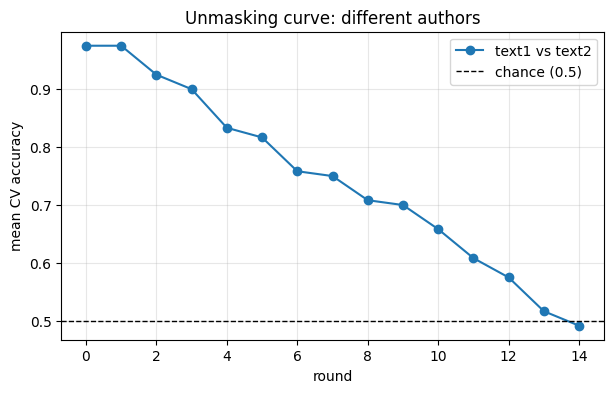

In [16]:
plt.figure(figsize=(7, 4))
plt.plot(res_diff.accuracies, marker="o", label="text1 vs text2")
plt.axhline(0.5, color="black", linewidth=1, linestyle="--", label="chance (0.5)")
plt.title("Unmasking curve: different authors")
plt.xlabel("round")
plt.ylabel("mean CV accuracy")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()


### What features get removed?

Because we use a *linear* classifier, each feature has a weight.
Large positive weights push predictions towards “right text”, large negative weights towards “left text”.

Below we show a few removed n-grams from the first round.


In [17]:
first_removed = res_diff.removed_feature_indices[0]
print("Removed features in round 0 (showing up to 20):")
for idx in first_removed[:20]:
    print(repr(vocab_diff[int(idx)]))


Removed features in round 0 (showing up to 20):
' th'
'the'
'he '
'er '
' to'
'her'
' he'
'as '
'es '
'hal'


## Demo B: Same author control (split `text1` into two halves)

As a rough control, we split a single book into two halves and pretend they are “two authors”.
We expect fewer stable stylistic differences, so accuracy should move towards chance **faster** than in Demo A.

(Reality check: topic shifts and narrative structure can still introduce differences even within one book.)


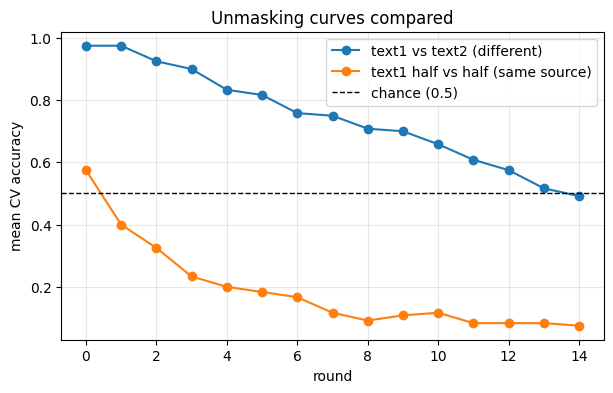

In [18]:
mid = len(text1.tokens) // 2
text1_left = text1.tokens[:mid]
text1_right = text1.tokens[mid:]

res_same, vocab_same = unmask_text_pair(
    text1_left,
    text1_right,
    ngram_n=3,
    chunk_size=500,
    bootstrap=True,
    n_chunks=60,
    top_n=250,
    rounds=15,
    n_delete=5,
    cv_folds=5,
    random_state=0,
)

plt.figure(figsize=(7, 4))
plt.plot(res_diff.accuracies, marker="o", label="text1 vs text2 (different)")
plt.plot(res_same.accuracies, marker="o", label="text1 half vs half (same source)")
plt.axhline(0.5, color="black", linewidth=1, linestyle="--", label="chance (0.5)")
plt.title("Unmasking curves compared")
plt.xlabel("round")
plt.ylabel("mean CV accuracy")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()


## Optional: turn a curve into a single score

Sometimes you want *one number* for quick comparisons (even though the curve is more informative).

A simple choice is the **mean accuracy above chance**. Bigger values mean the texts stay separable for longer.

- score ≈ 0 → quickly at chance (hard to distinguish)
- larger score → easier to distinguish (more stylistic differences)


In [19]:
def separability_score(accuracies: np.ndarray, *, chance: float = 0.5) -> float:
    """Summarize an unmasking curve as mean accuracy above chance."""
    acc = np.asarray(accuracies, dtype=float)
    return float(np.mean(acc - chance))

print('different-author score:', separability_score(res_diff.accuracies))
print('same-source score:', separability_score(res_same.accuracies))


different-author score: 0.2461111111111111
same-source score: -0.3105555555555555


## Interpreting unmasking curves

**How to read the plot**
- The y-axis is classification accuracy between left vs right chunks.
- The x-axis is the number of “unmasking rounds” (feature deletions).

**Typical patterns**
- **Slow decay**: many independent signals separate the texts → often consistent with *different authors or different registers*.
- **Fast decay**: only a small number of features mattered → often consistent with *the same author/style*.

**What unmasking does NOT guarantee**
- It is *not* a proof of authorship.
- Topic, genre, time period, and editing can dominate stylistic signals.
- Curves depend heavily on: chunk size, feature choice (char vs word n-grams), top_n, folds, and text length.

Treat unmasking as an **exploratory diagnostic**: it helps you *understand* what makes two texts separable.


## Try it yourself (experiments)

1. Change `ngram_n` from 3 to 4. What happens?
2. Set `bootstrap=False` and compare curves.
3. Compare `text2` vs `text3` (Austen vs Bible).
4. Increase `n_delete`. Does the curve drop faster? Why?
5. Decrease `chunk_size`. Do results get noisier?


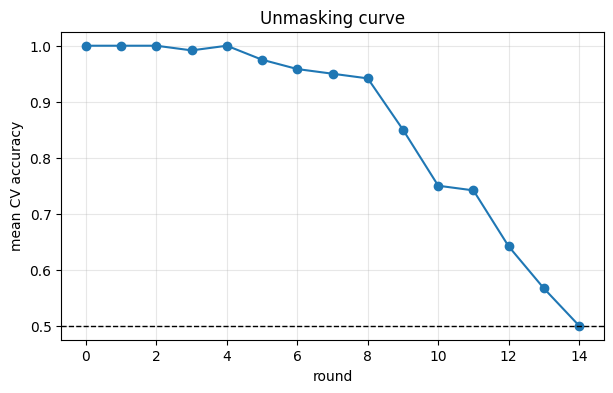

In [20]:
# Playground cell: edit parameters and rerun
res, vocab = unmask_text_pair(
    text2.tokens,
    text3.tokens,
    ngram_n=3,
    chunk_size=500,
    bootstrap=True,
    n_chunks=60,
    top_n=250,
    rounds=15,
    n_delete=5,
    cv_folds=5,
    random_state=0,
)

plt.figure(figsize=(7, 4))
plt.plot(res.accuracies, marker="o")
plt.axhline(0.5, color="black", linewidth=1, linestyle="--")
plt.title("Unmasking curve")
plt.xlabel("round")
plt.ylabel("mean CV accuracy")
plt.grid(True, alpha=0.3)
plt.show()
